# PCN on CIFAR-10

Image classification and class-conditional generation with the predictive-coding network.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torchvision
import torchvision.transforms as transforms
from pcn.model import PredictiveCodingNetwork
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix, f1_score
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm


In [4]:
# Test Again with CIFAR-10

# Define transformations for the CIFAR-10 dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize to [-1, 1]
])

# Load CIFAR-10 training and test datasets
train_dataset_cifar = torchvision.datasets.CIFAR10(root='../data', train=True, download=True, transform=transform)
test_dataset_cifar = torchvision.datasets.CIFAR10(root='../data', train=False, download=True, transform=transform)

# Train/Validation-Split aus dem Trainingsset - Test erst am Ende.
fit_cifar, val_cifar = random_split(
    train_dataset_cifar, [45000, 5000], generator=torch.Generator().manual_seed(42)
)

# Nur fuer die manuelle Test-Schleife weiter unten; fit()/evaluate() nehmen die
# Datasets direkt.
test_loader_cifar = DataLoader(test_dataset_cifar, batch_size=256, shuffle=False)


In [5]:
cifar_input_dim = int(np.prod(train_dataset_cifar[0][0].shape))
cifar_num_classes = len(train_dataset_cifar.classes)

# Warnung: die Relaxation laeuft T_infer mal pro Batch, das dominiert die Laufzeit.
# Erst mit wenigen Epochen testen bevor man hochdreht.
pcn_cifar = PredictiveCodingNetwork(
    dims=[cifar_input_dim, 1024, 512, 256],
    output_dim=cifar_num_classes
)

cifar_history = pcn_cifar.fit(
    fit_cifar,
    num_epochs=10,
    eta_infer=0.05,
    T_infer=50,
    batch_size=128,     # groessere Batches -> weniger Python-Overhead pro Schritt
    optimizer=torch.optim.Adam(pcn_cifar.parameters(), lr=1e-3, weight_decay=0.05),
    T_learn=1,
    validation_data=val_cifar,   # Test erst nach dem Training
    device="cuda",
    eval_every=1,
)


100%|██████████| 10/10 [05:36<00:00, 33.61s/it]


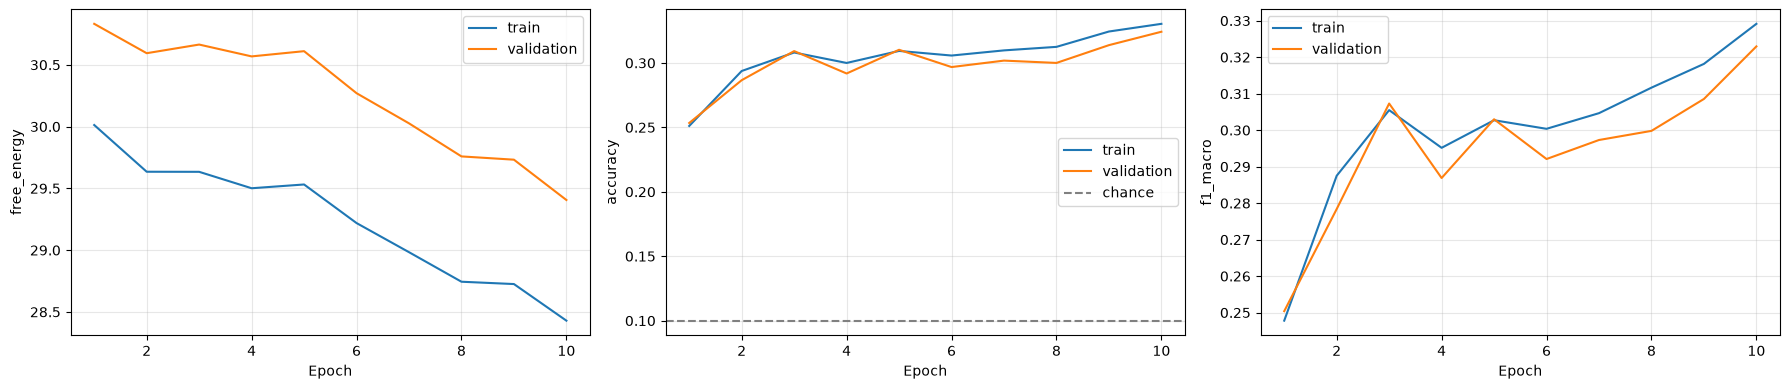

In [6]:
# plot trainings history
cifar_train_hist = pd.DataFrame(cifar_history["train"], index=cifar_history["epoch"])
cifar_val_hist = pd.DataFrame(cifar_history["validation"], index=cifar_history["epoch"])

fig, (ax_loss, ax_acc, ax_f1) = plt.subplots(1, 3, figsize=(18, 4))
for ax, metric in [(ax_loss, "free_energy"), (ax_acc, "accuracy"), (ax_f1, "f1_macro")]:
    ax.plot(cifar_train_hist[metric], label="train")
    ax.plot(cifar_val_hist[metric], label="validation")
    ax.set_xlabel("Epoch"); ax.set_ylabel(metric); ax.legend(); ax.grid(alpha=0.3)
ax_acc.axhline(1 / cifar_num_classes, ls="--", c="grey", label="chance")
ax_acc.legend()

plt.tight_layout()
plt.show()


In [7]:
# evaluate the NN on the CIFAR test set
# (vorher lief hier pcn auf X_test_tensor, also das Herz-Modell auf Herz-Daten)
cifar_device = next(pcn_cifar.parameters()).device
cifar_true, cifar_pred = [], []

for x_batch, y_batch in tqdm(test_loader_cifar, desc="CIFAR test"):
    out = pcn_cifar.run(
        mode="predictive",
        x=x_batch.view(x_batch.size(0), -1),
        eta_infer=0.05,
        T_infer=50,
        device=cifar_device,
    )
    cifar_pred.append(out.output_prediction.argmax(dim=1).cpu())
    cifar_true.append(y_batch)

cifar_true = torch.cat(cifar_true)
cifar_pred = torch.cat(cifar_pred)

print("CIFAR-10 Test Accuracy:", accuracy_score(cifar_true, cifar_pred))
print("CIFAR-10 Test F1 Score:", f1_score(cifar_true, cifar_pred, average='weighted'))

CIFAR test: 100%|██████████| 40/40 [00:08<00:00,  5.00it/s]

CIFAR-10 Test Accuracy: 0.3239
CIFAR-10 Test F1 Score: 0.3217685322514053


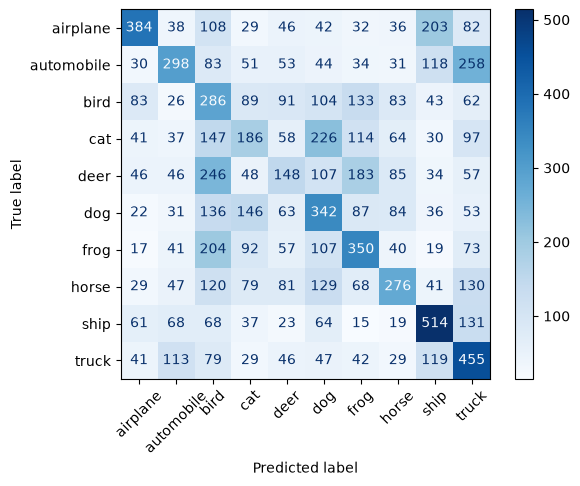

In [8]:
# Confusion Matrix
cm = confusion_matrix(cifar_true, cifar_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_dataset_cifar.classes)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.show()

100%|██████████| 10/10 [00:02<00:00,  3.39it/s]


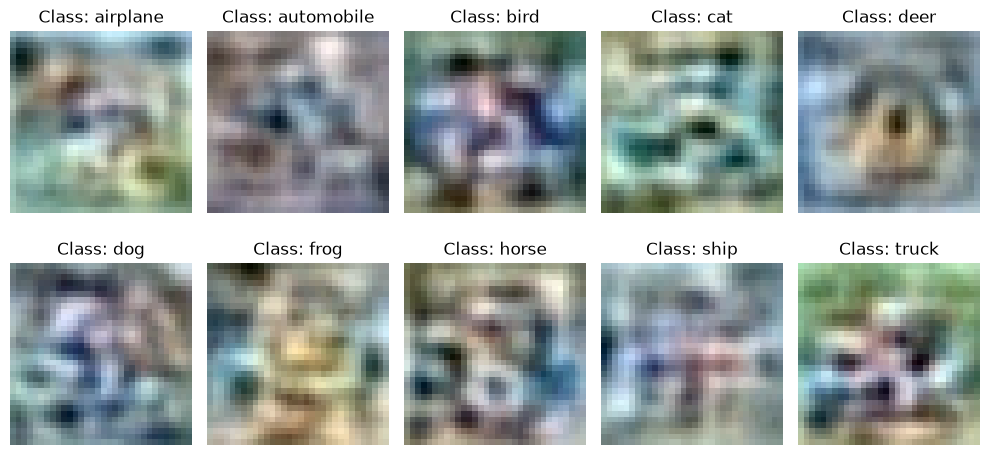

In [44]:
# Erstellt eine Figur mit passender Größe für ein 3x3 Raster
fig = plt.figure(figsize=(10, 5))
for class_idx in tqdm(range(cifar_num_classes)):
    # Generiert das Bild für die aktuelle Ziffer (0 bis 8)
    image = pcn_cifar.run(mode="generative", y=class_idx, eta_infer=0.05, T_infer=1000)
    
    # Umformen in 28x28 Pixel
    image_3d = image.input_state.view(3, 32, 32)

    # Definiert die Position im 3x3 Raster (Index startet bei 1)
    plt.subplot(2, 5, class_idx + 1)
    image_np = image_3d.cpu().numpy().transpose(1, 2, 0)

    
    # Normalisierung rückgängig machen: [-1, 1] -> [0, 1]
    # Ersetze die feste Formel durch diese dynamische Normalisierung:
    img_min = image_3d.min()
    img_max = image_3d.max()

    # Skaliert die tatsächlichen Werte exakt auf das Intervall [0.0, 1.0]
    normalised_image_3d = (image_3d - img_min) / (img_max - img_min + 1e-5)
    plt.imshow(normalised_image_3d.cpu().numpy().transpose(1, 2, 0), cmap='gray')
    plt.title(f"Class: {train_dataset_cifar.classes[class_idx]}")
    plt.axis('off')  # Blendet die Achsen aus

# Optimiert die Abstände zwischen den Bildern, damit nichts überlappt
plt.tight_layout()
plt.show()


100%|██████████| 10/10 [00:55<00:00,  5.60s/it]


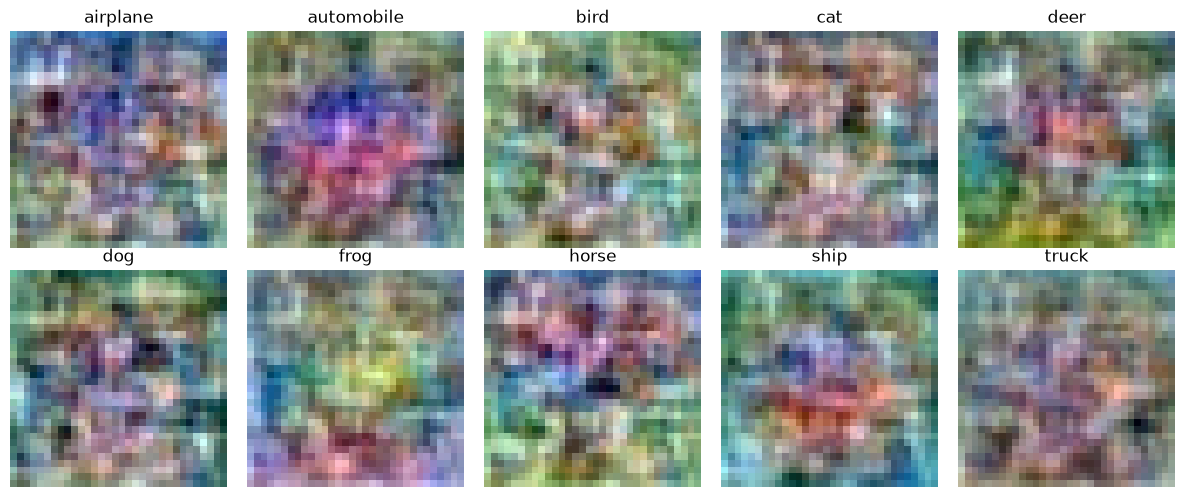

In [43]:
# 1. Figure für ein 2x5 Raster erstellen (angepasste Proportionen)
fig = plt.figure(figsize=(12, 5)) 
n = 100  # Anzahl der Bilder pro Ziffer
cifar_device = next(pcn_cifar.parameters()).device  

for class_idx in tqdm(range(cifar_num_classes)):     
    image_sum = torch.zeros((3, 32, 32), device=cifar_device)  
    
    for _ in range(n):  
        # Generiert das Bild für die aktuelle Klasse
        image = pcn_cifar.run(mode="generative", y=class_idx, eta_infer=0.05, T_infer=200)
        
        # .reshape() ist sicherer als .view(), falls die Memory-Struktur nicht contiguous ist
        # .squeeze() entfernt eventuelle Single-Batch-Dimensionen (1, 3, 32, 32) -> (3, 32, 32)
        img_tensor = image.input_state.squeeze().reshape(3, 32, 32)
        image_sum += img_tensor      
        
    # Durchschnittsbild berechnen     
    image_3d = image_sum / n      
    
    # Normalisierung rückgängig machen: [-1, 1] -> [0, 1]
    # Ersetze die feste Formel durch diese dynamische Normalisierung:
    img_min = image_3d.min()
    img_max = image_3d.max()

    # Skaliert die tatsächlichen Werte exakt auf das Intervall [0.0, 1.0]
    normalised_image_3d = (image_3d - img_min) / (img_max - img_min + 1e-5)    
    
    # Position im 2x5 Raster definieren (Index startet bei 1)     
    plt.subplot(2, 5, class_idx + 1)      
    
    # Bild anzeigen (Permute/Transpose für Matplotlib: Von HWC auf CHW)
    # cmap='gray' wird bei 3-Kanal-Bildern (RGB) von imshow ignoriert, schadet aber nicht
    plt.imshow(normalised_image_3d.cpu().numpy().transpose(1, 2, 0))     
    plt.title(f"{train_dataset_cifar.classes[class_idx]}")     
    plt.axis('off')  

plt.tight_layout() 
plt.show()
